In [1]:
import os
import logging
from typing import TypedDict, List, Optional
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [2]:
load_dotenv()

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
print(f'   Model: {llm.model_name}')

   Model: gpt-4o-mini


Load the Store and Build All Retrievers

In [3]:
# Path to the domain-tagged store
persist_dir = r'C:\Users\USER\rag_course\chroma_db_domain'

# Embedding model + vector store
embeddings = OpenAIEmbeddings()
vectorstore = Chroma(
    persist_directory=persist_dir,
    embedding_function=embeddings,
)

# Three retrievers — one per domain
crops_retriever = vectorstore.as_retriever(
    search_kwargs={'k': 4, 'filter': {'domain': 'crops'}}
)

health_retriever = vectorstore.as_retriever(
    search_kwargs={'k': 4, 'filter': {'domain': 'health'}}
)

both_retriever = vectorstore.as_retriever(
    search_kwargs={'k': 4}
)

print(f'Store loaded — {vectorstore._collection.count()} chunks')
print(f'   crops_retriever:  filter=domain:crops')
print(f'   health_retriever: filter=domain:health')
print(f'   both_retriever:   no filter (searches all)')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Store loaded — 80 chunks
   crops_retriever:  filter=domain:crops
   health_retriever: filter=domain:health
   both_retriever:   no filter (searches all)


All the Chains

In [4]:
# Chain 1: Intent classifier (Self-RAG)
intent_prompt = ChatPromptTemplate.from_messages([
  ('system',
     'Decide if a question needs the knowledge base.\n'
     '- RETRIEVE: about crops, plant diseases, treatments, Nigeria public health\n'
     '- DIRECT: greetings, math, general knowledge, chit-chat\n'
     'Answer with exactly one word: RETRIEVE or DIRECT.'),  
  ('human', '{query}'),
])

intent_classifier = intent_prompt | llm | StrOutputParser()


# Chain 2: Domain classifier (Adaptive RAG)
domain_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'Classify the question into one of three domains:\n'
     '- CROPS: crops, plant diseases, livestock\n'
     '- HEALTH: human diseases, Nigeria public health\n'
     '- BOTH: mentions both domains\n'
     'Answer with exactly one word: CROPS, HEALTH, or BOTH.'),
    ('human', '{query}'),
])

domain_classifier = domain_prompt | llm | StrOutputParser()


# Chain 3: Relevance grader (Corrective RAG)
grader_prompt = ChatPromptTemplate.from_messages([
    ('system', 'Given a query and a document, decide if the document is relevant. Answer with exactly one word: YES or NO.'),
    ('human', 'Query: {query}\n\nDocument:\n{document}'),
])

relevance_grader = grader_prompt | llm | StrOutputParser()


# Chain 4: Query rewriter (Corrective RAG)
rewriter_prompt = ChatPromptTemplate.from_messages([
    ('system', 'Rewrite the query to improve document retrieval. Output only the rewritten query.'),
    ('human', '{query}'),
])

query_rewriter = rewriter_prompt | llm | StrOutputParser()


# Chain 5: Answer from documents
answer_docs_prompt = ChatPromptTemplate.from_messages([
    ('system', 'Answer using ONLY the context below. If the answer is not in the context, say "I don\'t know".'),
    ('human', 'Context:\n{context}\n\nQuery: {query}'),
])

answer_from_docs = answer_docs_prompt | llm | StrOutputParser()


# Chain 6: Direct answer (no retrieval) 
direct_answer_prompt = ChatPromptTemplate.from_messages([
    ('system', 'Answer the question directly using your own knowledge. Be honest if you don\'t know.'),
    ('human', '{query}'),
])

answer_directly = direct_answer_prompt | llm | StrOutputParser()


The Unified State Schema

In [5]:
class AgenticRAGState(TypedDict, total=False):
    '''
    State for the full Agentic RAG pipeline.

    Fields:
        query: User's original question
        intent: DIRECT or RETRIEVE
        domain: CROPS, HEALTH, or BOTH
        rewritten_query: Rewritten query (set on retry only)
        retrieved_docs: All chunks from retrieval
        corrected_docs: Chunks that passed grading
        retry_count: How many retries so far
        answer: Final answer to return
    '''

    query: str
    intent: str
    domain: str
    rewritten_query: str
    retrieved_docs: List[Document]
    corrected_docs: List[Document]
    retry_count: int
    answer: str


print('AgenticRAGState defined')
print(f'   Fields: {list(AgenticRAGState.__annotations__.keys())}')

AgenticRAGState defined
   Fields: ['query', 'intent', 'domain', 'rewritten_query', 'retrieved_docs', 'corrected_docs', 'retry_count', 'answer']


The classify_intent_node Function

In [6]:
def classify_intent_node(state: AgenticRAGState) -> dict:
    '''
    Classify the query as needing retrieval or not.

    Reads:  state['query']
    Writes: state['intent']  (DIRECT or RETRIEVE)
    '''
    
    intent = intent_classifier.invoke({
        'query': state['query']
    }).strip().upper()
    
    print(f'Intent: {intent}')
    return {
        'intent': intent
    }

Test 

In [7]:
test = {'query': 'How do I treat cassava mosaic disease?'}
result = classify_intent_node(test)
print(f'Returned: {result}')

Intent: RETRIEVE
Returned: {'intent': 'RETRIEVE'}


In [8]:
test = {'query': 'What is 2 + 2?'}
result = classify_intent_node(test)
print(f'Returned: {result}')

Intent: DIRECT
Returned: {'intent': 'DIRECT'}


The classify_domain_node Function

In [9]:
def classify_domain_node(state: AgenticRAGState) -> dict:
    '''
    Classify the query into a domain: CROPS, HEALTH, or BOTH.

    Reads:  state['query']
    Writes: state['domain']  (CROPS, HEALTH, or BOTH)
    '''
    
    domain = domain_classifier.invoke({
        'query': state['query']
    }).strip().upper()
    
    print(f'Domain: {domain}')
    return {'domain': domain}

In [10]:
test = {'query': 'How do I treat cassava mosaic disease?'}
result = classify_domain_node(test)
print(f'Returned: {result}')

Domain: CROPS
Returned: {'domain': 'CROPS'}


In [11]:
test = {'query': 'What are the top causes of death in Nigeria?'}
result = classify_domain_node(test)
print(f'Returned: {result}')

Domain: HEALTH
Returned: {'domain': 'HEALTH'}


In [12]:
test = {'query': 'Compare malaria and maize smut'}
result = classify_domain_node(test)
print(f'Returned: {result}')

Domain: BOTH
Returned: {'domain': 'BOTH'}


The retrieve_crops_node Function

In [13]:
def retrieve_crops_node(state: AgenticRAGState) -> dict:
    '''
    Retrieve documents from the crops domain only.

    Reads:  state['query'] or state['rewritten_query']
    Writes: state['retrieved_docs']
    '''
    
    query = state.get('rewritten_query') or state['query']
    
    docs = crops_retriever.invoke(query)
    print(f'Retrieved {len(docs)} crops docs for "{query}"')
    
    return {
        'retrieved_docs': docs
    }

    

In [14]:
test = {'query': 'How do I treat cassava mosaic disease?'}
result = retrieve_crops_node(test)
print(f'Returned {len(result["retrieved_docs"])} docs')

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Retrieved 4 crops docs for "How do I treat cassava mosaic disease?"
Returned 4 docs


The retrieve_health_node Function

In [15]:
def retrieve_health_node(state: AgenticRAGState) -> dict:
    '''
    Retrieve documents from the health domain only.

    Reads:  state['query'] or state['rewritten_query']
    Writes: state['retrieved_docs']
    '''
    
    query = state.get('rewritten_query') or state['query']
    
    docs = health_retriever.invoke(query)
    print(f'Retrieved {len(docs)} health docs for: "{query}"')
    return {'retrieved_docs': docs}

In [16]:
test = {'query': 'What are the top causes of death in Nigeria?'}
result = retrieve_health_node(test)
print(f'Returned {len(result["retrieved_docs"])} docs')

Retrieved 4 health docs for: "What are the top causes of death in Nigeria?"
Returned 4 docs


The retrieve_both_node Function

In [17]:
def retrieve_both_node(state: AgenticRAGState) -> dict:
    '''
    Retrieve documents from both crops and health domains.

    Reads:  state['query'] or state['rewritten_query']
    Writes: state['retrieved_docs']
    '''
    query = state.get('rewritten_query') or state['query']
    docs = both_retriever.invoke(query)
    print(f'Retrieved {len(docs)} docs (both domains) for: "{query}"')
    return {'retrieved_docs': docs}

In [18]:
test = {'query': 'Compare malaria and maize smut'}
result = retrieve_both_node(test)
print(f'Returned {len(result["retrieved_docs"])} docs')

Retrieved 4 docs (both domains) for: "Compare malaria and maize smut"
Returned 4 docs


The filter_relevant_node Function

In [19]:
def filter_relevant_node(state: AgenticRAGState) -> dict:
    '''
    Grade each retrieved doc and keep only the relevant ones.

    Reads:  state['query'], state['retrieved_docs']
    Writes: state['corrected_docs']
    '''
    
    relevant_docs = []
    for doc in state['retrieved_docs']:
        relevance = relevance_grader.invoke({
            'query': state['query'],
            'document': doc.page_content
        }).strip().upper()
        
        if 'YES' in relevance:
            relevant_docs.append(doc)
    
    print(f'Graded: {len(relevant_docs)}/{len(state["retrieved_docs"])} relevant')
    
    return {
        'corrected_docs': relevant_docs
    }

In [20]:
state = {'query': 'How do I treat cassava mosaic disease?'}
state.update(retrieve_crops_node(state))
state.update(filter_relevant_node(state))

print(f'\nCorrected docs: {len(state["corrected_docs"])}')
print(state['corrected_docs'])

Retrieved 4 crops docs for "How do I treat cassava mosaic disease?"
Graded: 3/4 relevant

Corrected docs: 3
[Document(metadata={'domain': 'crops', 'file_name': 'crop_disease.pdf', 'page': 27, 'source': 'C:\\Users\\USER\\rag_course\\04_data_ingestion_document_processing\\data\\crop_disease.pdf'}, page_content='Management\nO Use of disease free planting materials.\nO The uprooted plants should be carried \naway from the field and exposed to the \nsunlight for drying and then burned to kill \nthe viruses.\nO Do not plant cassava close to infected \nfields as the insect vectors will transport \nthe disease to healthy plants.'), Document(metadata={'domain': 'crops', 'file_name': 'agriculture.html', 'source': 'C:\\Users\\USER\\rag_course\\04_data_ingestion_document_processing\\data\\agriculture.html', 'title': 'Agriculture in Nigeria: Crops, Livestock, and Disease Management'}, page_content='Common Crop Diseases and Their Control\n\n1. Cassava Mosaic Disease\nAffected Crop: Cassava\nSymptoms

In [21]:
state = {'query': 'How do I treat cassava mosaic disease?'}
state.update(retrieve_crops_node(state))
state.update(filter_relevant_node(state))

print(f'\nCorrected docs: {len(state["corrected_docs"])}\n')
for i, doc in enumerate(state['corrected_docs']):
    print(f'--- Doc {i} ---')
    print(f'Source: {doc.metadata.get("file_name")}')
    print(f'Content: {doc.page_content[:200]}')
    print()

Retrieved 4 crops docs for "How do I treat cassava mosaic disease?"
Graded: 3/4 relevant

Corrected docs: 3

--- Doc 0 ---
Source: crop_disease.pdf
Content: Management
O Use of disease free planting materials.
O The uprooted plants should be carried 
away from the field and exposed to the 
sunlight for drying and then burned to kill 
the viruses.
O Do not

--- Doc 1 ---
Source: agriculture.html
Content: Common Crop Diseases and Their Control

1. Cassava Mosaic Disease
Affected Crop: Cassava
Symptoms: Yellowing and mottling of leaves, stunted growth, reduced yield.
Control/Cure: Use disease-free cutti

--- Doc 2 ---
Source: agriculture.txt
Content: Fisheries and aquaculture provide employment and protein for many families. Catfish and tilapia are commonly farmed in ponds and tanks.

Common Crop Diseases and Control

1. Cassava Mosaic Disease
   



The rewrite_question_node Function

In [22]:
def rewrite_question_node(state: AgenticRAGState) -> dict:
    '''
    Rewrite the query to improve retrieval (used on retry).

    Reads:  state['query'], state['retry_count']
    Writes: state['rewritten_query'], state['retry_count']
    '''
    
    new_query = query_rewriter.invoke({
        'query': state['query']
    }).strip()
    
    return {
        'rewritten_query': new_query,
        'retry_count': (state.get('retry_count') or 0) + 1
    }
    

In [23]:
state = {'query': 'How do I treat tomato blight?'}
result = rewrite_question_node(state)
print(f'\nReturned: {result}')


Returned: {'rewritten_query': 'What are the effective methods for treating tomato blight?', 'retry_count': 1}


In [24]:
state = {'query': 'What about cassava disease?'}
result = rewrite_question_node(state)
print(f'\nReturned: {result}')


Returned: {'rewritten_query': 'What are the common diseases affecting cassava and their impact on crop yield?', 'retry_count': 1}


The answer_from_docs_node Function

In [25]:
def answer_from_docs_node(state: AgenticRAGState) -> dict:
    '''
    Answer the query using the corrected (relevant) docs.

    Reads:  state['query'], state['corrected_docs']
    Writes: state['answer']
    '''
    
    context = '\n\n'.join(doc.page_content for doc in state['corrected_docs'])
    answer = answer_from_docs.invoke({
        'context': context,
        'query': state['query'],
    })
    
    print('Answered from docs')
    return {'answer': answer}

Test

In [26]:
state = {'query': 'How do I treat cassava mosaic disease?'}
state.update(retrieve_crops_node(state))
state.update(filter_relevant_node(state))
state.update(answer_from_docs_node(state))

print(f'\nAnswer:\n{state["answer"]}')

Retrieved 4 crops docs for "How do I treat cassava mosaic disease?"
Graded: 3/4 relevant
Answered from docs

Answer:
To treat cassava mosaic disease, use disease-free cuttings, plant resistant varieties, and remove infected plants early.


The answer_directly_node Function

In [27]:
def answer_directly_node(state: AgenticRAGState) -> dict:
    '''
    Answer directly from LLM knowledge (used for DIRECT intent or fallback).

    Reads:  state['query']
    Writes: state['answer']
    '''
    
    answer = answer_directly.invoke({
        'query': state['query']
    })
    
    print('Answered directly (no retrieval)')
    return {'answer': answer}

Test 1 — Direct Answer

In [28]:
state = {'query': 'What is total of square of 3 and cube of 2?'}
state.update(answer_directly_node(state))
print(f'\n{state["answer"]}')

Answered directly (no retrieval)

The square of 3 is \(3^2 = 9\) and the cube of 2 is \(2^3 = 8\). 

Adding these together gives: 

\(9 + 8 = 17\).

So, the total of the square of 3 and the cube of 2 is 17.


Test 2 — Fallback (Unknown Topic)

In [29]:
state = {'query': 'How do I treat tomato blight?'}
state.update(answer_directly_node(state))
print(f'\n{state["answer"]}')

Answered directly (no retrieval)

To treat tomato blight, follow these steps:

1. **Identify the Type of Blight**: There are two main types of blight affecting tomatoes: early blight (caused by the fungus Alternaria solani) and late blight (caused by the pathogen Phytophthora infestans). Early blight typically shows dark spots on older leaves, while late blight causes water-soaked spots and can lead to rapid plant decline.

2. **Remove Infected Plant Parts**: Cut away and dispose of any infected leaves, stems, or fruit. Be sure to sanitize your tools to prevent spreading the disease.

3. **Improve Air Circulation**: Space your plants properly and prune them to allow for better airflow, which can help reduce humidity and the spread of fungal spores.

4. **Watering Practices**: Water at the base of the plants rather than overhead to keep the foliage dry. Water in the morning to allow any moisture on the leaves to dry out during the day.

5. **Fungicides**: Apply fungicides that are effec

Router 1 — After Intent Classification

In [30]:
def route_by_intent(state: AgenticRAGState) -> str:
    '''
    Route based on Self-RAG intent — retrieve or direct answer.

    Reads: state['intent']  (DIRECT or RETRIEVE)

    '''
    
    if 'RETRIEVE' in state['intent']:
        print('Intent route: RETRIEVE -> classify domain')    
        return 'retrieve'
    
    else:
        print('Intent route: DIRECT -> answer directly')
        return 'direct'

In [31]:
# Test It

# Test RETRIEVE path
route_by_intent({
    'intent': 'RETRIEVE'
})

# Test DIRECT path
route_by_intent({
    'intent': 'DIRECT'
})

Intent route: RETRIEVE -> classify domain
Intent route: DIRECT -> answer directly


'direct'

 Router 2 — After Domain Classification

In [32]:
def route_by_domain(state: AgenticRAGState) -> str:
    '''
    Route to the correct retriever based on the domain.

    Reads: state['domain']  (CROPS, HEALTH, or BOTH)
    '''
    
    if 'CROPS' in state['domain']:
        print('Domain route: CROPS → retrieve_crops')
        return 'crops'
    elif 'HEALTH' in state['domain']:
        print('Domain route: HEALTH → retrieve_health')
        return 'health'
    else:
        print('Domain route: BOTH → retrieve_both')
        return 'both'
    

Test All Three Branches

In [33]:
print(route_by_domain({'domain': 'CROPS'}))
print(route_by_domain({'domain': 'HEALTH'}))
print(route_by_domain({'domain': 'BOTH'}))

Domain route: CROPS → retrieve_crops
crops
Domain route: HEALTH → retrieve_health
health
Domain route: BOTH → retrieve_both
both


Router 3 — After Grading (Corrective RAG)

In [34]:
def route_after_grading(state: AgenticRAGState) -> str:
    '''Decide next step after grading: answer, retry, or fallback.

    Reads: state['corrected_docs'], state['retry_count']
    '''
    
    n_relevant = len(state.get('corrected_docs') or [])
    
    retried = (state.get('retry_count') or 0) > 0
    
    if n_relevant >= 1:
        print(f'Grade route: {n_relevant} relevant -> answer_from_docs')
        return 'answer'
    
    elif not retried:
        print('Grade route: 0 relevant, no retry yet -> rewrite_question')
        return 'retry'
    
    else:
        print('Grade route: retry failed -> answer_directly')
        return 'fallback'

Test All Three Branches

In [35]:
print(route_after_grading({'corrected_docs': [1, 2, 3], 'retry_count': 0}))
print(route_after_grading({'corrected_docs': [], 'retry_count': 0}))
print(route_after_grading({'corrected_docs': [], 'retry_count': 1}))

Grade route: 3 relevant -> answer_from_docs
answer
Grade route: 0 relevant, no retry yet -> rewrite_question
retry
Grade route: retry failed -> answer_directly
fallback


Graph Assembly

In [36]:
# Create the graph
builder = StateGraph(AgenticRAGState)

# Register all nodes
builder.add_node('classify_intent', classify_intent_node)
builder.add_node('classify_domain', classify_domain_node)
builder.add_node('retrieve_crops', retrieve_crops_node)
builder.add_node('retrieve_health', retrieve_health_node)
builder.add_node('retrieve_both', retrieve_both_node)
builder.add_node('filter_relevant', filter_relevant_node)
builder.add_node('rewrite_question', rewrite_question_node)
builder.add_node('answer_from_docs', answer_from_docs_node)
builder.add_node('answer_directly', answer_directly_node)

# START → classify_intent
builder.add_edge(START, 'classify_intent')

# Router 1 — after intent classification (RETRIEVE vs DIRECT)
builder.add_conditional_edges(
    'classify_intent',
    route_by_intent,
    {
        'retrieve': 'classify_domain',
        'direct': 'answer_directly'
    }
)

# Router 2 — after domain classification (CROPS / HEALTH / BOTH)
builder.add_conditional_edges(
    'classify_domain',
    route_by_domain,
    {
        'crops': 'retrieve_crops',
        'health': 'retrieve_health',
        'both': 'retrieve_both'
    }
)

# All three retrievers converge on filter_relevant
builder.add_edge('retrieve_crops', 'filter_relevant')
builder.add_edge('retrieve_health', 'filter_relevant')
builder.add_edge('retrieve_both', 'filter_relevant')

# Router 3 — after grading (answer / retry / fallback)
builder.add_conditional_edges(
    'filter_relevant',
    route_after_grading,
    {
        'answer': 'answer_from_docs',
        'retry': 'rewrite_question',
        'fallback': 'answer_directly'
    }
)

# Retry loops back to domain classification with the new query
builder.add_edge('rewrite_question', 'classify_domain')

# Both answer nodes end the graph
builder.add_edge('answer_from_docs', END)
builder.add_edge('answer_directly', END)

# Compile
agentic_app = builder.compile()

print('Full Agentic RAG graph compiled')

Full Agentic RAG graph compiled


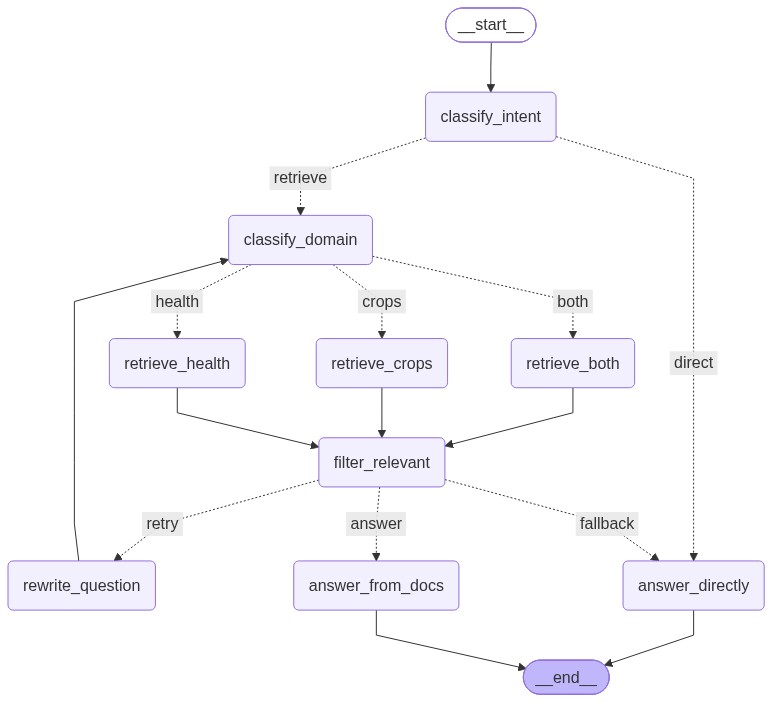

Graph rendered


In [37]:
try:
    display(Image(agentic_app.get_graph().draw_mermaid_png()))
    print('Graph rendered')
except Exception as e:
    print(f'PNG failed: {e}')
    print('\nASCII fallback:')
    print(agentic_app.get_graph().draw_ascii())

Full Test Suite — 6 Question Types

In [38]:
# Six questions covering every path in the graph
test_questions = [
    'Hello, how are you?',                              # DIRECT path
    'What is 2 + 2?',                                   # DIRECT path
    'How do I treat cassava mosaic disease?',           # RETRIEVE → CROPS → answer
    'What are the top causes of death in Nigeria?',     # RETRIEVE → HEALTH → answer
    'Compare malaria and maize smut',                   # RETRIEVE → BOTH → answer
    'How do I treat tomato blight?',                    # RETRIEVE → retry → fallback
]

for q in test_questions:
    print(f'\n{"=" * 70}')
    print(f'❓ {q}')
    print('=' * 70)
    result = agentic_app.invoke({'query': q})
    print(f'\n{result["answer"][:250]}')


❓ Hello, how are you?
Intent: DIRECT
Intent route: DIRECT -> answer directly
Answered directly (no retrieval)

Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?

❓ What is 2 + 2?
Intent: DIRECT
Intent route: DIRECT -> answer directly
Answered directly (no retrieval)

2 + 2 equals 4.

❓ How do I treat cassava mosaic disease?
Intent: RETRIEVE
Intent route: RETRIEVE -> classify domain
Domain: CROPS
Domain route: CROPS → retrieve_crops
Retrieved 4 crops docs for "How do I treat cassava mosaic disease?"
Graded: 3/4 relevant
Grade route: 3 relevant -> answer_from_docs
Answered from docs

To treat cassava mosaic disease, use disease-free cuttings, plant resistant varieties, and remove infected plants early.

❓ What are the top causes of death in Nigeria?
Intent: RETRIEVE
Intent route: RETRIEVE -> classify domain
Domain: HEALTH
Domain route: HEALTH → retrieve_health
Retrieved 4 health docs for: "What are the top causes of deat

In [39]:
# Just test 3
result = agentic_app.invoke({'query': 'How do I treat cassava mosaic disease?'})
print(f'\n{result["answer"]}')

Intent: RETRIEVE
Intent route: RETRIEVE -> classify domain
Domain: CROPS
Domain route: CROPS → retrieve_crops
Retrieved 4 crops docs for "How do I treat cassava mosaic disease?"
Graded: 3/4 relevant
Grade route: 3 relevant -> answer_from_docs
Answered from docs

To treat cassava mosaic disease, use disease-free cuttings, plant resistant varieties, and remove infected plants early.


In [40]:
# Just test 4
result = agentic_app.invoke({'query': 'What are the top causes of death in Nigeria?'})
print(f'\n{result["answer"]}')

Intent: RETRIEVE
Intent route: RETRIEVE -> classify domain
Domain: HEALTH
Domain route: HEALTH → retrieve_health
Retrieved 4 health docs for: "What are the top causes of death in Nigeria?"
Graded: 4/4 relevant
Grade route: 4 relevant -> answer_from_docs
Answered from docs

The top causes of death in Nigeria are malaria, lower respiratory infections, HIV/AIDS, diarrheal diseases, road injuries, protein-energy malnutrition, cancer, meningitis, stroke, and tuberculosis.


In [41]:
# Just test 5
result = agentic_app.invoke({'query': 'Compare malaria and maize smut'})
print(f'\n💬 {result["answer"]}')

Intent: RETRIEVE
Intent route: RETRIEVE -> classify domain
Domain: BOTH
Domain route: BOTH → retrieve_both
Retrieved 4 docs (both domains) for: "Compare malaria and maize smut"
Graded: 0/4 relevant
Grade route: 0 relevant, no retry yet -> rewrite_question
Domain: BOTH
Domain route: BOTH → retrieve_both
Retrieved 4 docs (both domains) for: "Compare and contrast the characteristics, life cycles, and impacts of malaria and maize smut."
Graded: 0/4 relevant
Grade route: retry failed -> answer_directly
Answered directly (no retrieval)

💬 Malaria and maize smut are two very different biological phenomena, each with distinct characteristics and implications.

**Malaria:**
- **Type:** Malaria is a disease caused by parasites of the genus Plasmodium, which are transmitted to humans through the bites of infected female Anopheles mosquitoes.
- **Impact on Humans:** It is a significant global health issue, particularly in tropical and subtropical regions. Symptoms include fever, chills, and flu-li

In [42]:
# Just test 6
result = agentic_app.invoke({'query': 'How do I treat tomato blight?'})
print(f'\n💬 {result["answer"]}')

Intent: RETRIEVE
Intent route: RETRIEVE -> classify domain
Domain: CROPS
Domain route: CROPS → retrieve_crops
Retrieved 4 crops docs for "How do I treat tomato blight?"
Graded: 2/4 relevant
Grade route: 2 relevant -> answer_from_docs
Answered from docs

💬 I don't know.
